In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people

In [24]:
import shutil
import os

lfw_home = os.path.expanduser('~/scikit_learn_data/lfw_home') #Corrupted Data Folder

if os.path.exists(lfw_home):
    shutil.rmtree(lfw_home)

In [19]:
lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=0.4, slice_=None)

X_raw = lfw_people.data
y_raw = lfw_people.target
target_names = lfw_people.target_names
images = lfw_people.images

arnold_label = np.where(target_names == "Arnold Schwarzenegger")[0][0]

y_binary = np.where(y_raw == arnold_label, 1, 0)

arnold_count = np.sum(y_binary == 1)
others_count = np.sum(y_binary == 0)

print(len(y_binary))
print()
print(arnold_count)
print()
print(others_count)

3023

42

2981


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [21]:
X_normalized = X_raw / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y_binary,
    test_size=0.25,
    random_state=42,
    stratify=y_binary
)

print(X_train.shape)
print()
print(X_test.shape)

(2267, 10000)

(756, 10000)


In [22]:
n_components = 150

pca = PCA(n_components=n_components, whiten=True, random_state=42).fit(X_train)

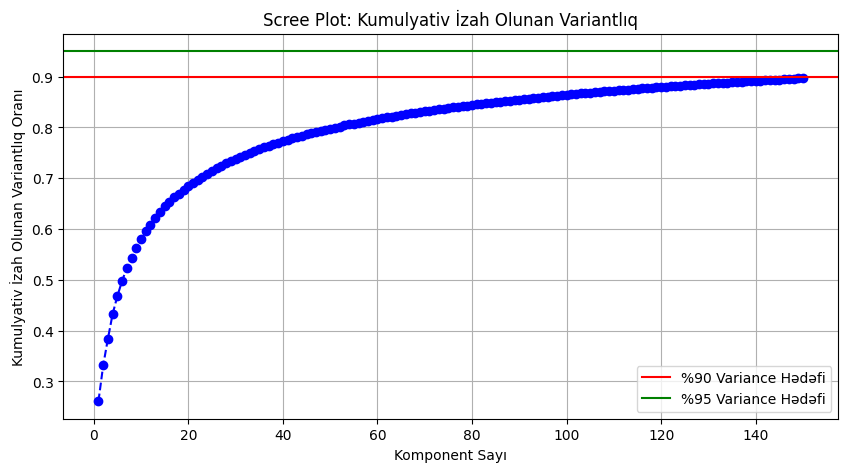

In [23]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-', label='%90 Variance Hədəfi')
plt.axhline(y=0.95, color='g', linestyle='-', label='%95 Variance Hədəfi')
plt.title('Scree Plot: Kumulyativ İzah Olunan Variantlıq')
plt.xlabel('Komponent Sayı')
plt.ylabel('Kumulyativ İzah Olunan Variantlıq Oranı')
plt.grid(True)
plt.legend()
plt.show()

In [25]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(components_90)

1


In [26]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
n_components_optimal = 50
pca_optimal = PCA(n_components=n_components_optimal, whiten=True, random_state=42)

X_train_pca = pca_optimal.fit_transform(X_train)
X_test_pca = pca_optimal.transform(X_test)

lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_pca, y_train)
lr_preds = lr_model.predict(X_test_pca)

dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt_model.fit(X_train_pca, y_train)
dt_preds = dt_model.predict(X_test_pca)

svm_base = SVC(class_weight='balanced', random_state=42)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(svm_base, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

best_svm_model = grid_search.best_estimator_
svm_preds = best_svm_model.predict(X_test_pca)

print(grid_search.best_params_)

{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


In [28]:
models = {
    "Logistic Regression": lr_preds,
    "Decision Tree": dt_preds,
    "Optimized SVM": svm_preds
}

for model_name, preds in models.items():
    print(f" {model_name}" )
    print(classification_report(y_test, preds, target_names=['Others', 'Arnold']))

 Logistic Regression
              precision    recall  f1-score   support

      Others       0.99      0.90      0.94       745
      Arnold       0.05      0.36      0.09        11

    accuracy                           0.89       756
   macro avg       0.52      0.63      0.51       756
weighted avg       0.98      0.89      0.93       756

 Decision Tree
              precision    recall  f1-score   support

      Others       0.99      0.92      0.95       745
      Arnold       0.06      0.36      0.11        11

    accuracy                           0.91       756
   macro avg       0.53      0.64      0.53       756
weighted avg       0.98      0.91      0.94       756

 Optimized SVM
              precision    recall  f1-score   support

      Others       0.99      0.98      0.99       745
      Arnold       0.08      0.09      0.08        11

    accuracy                           0.97       756
   macro avg       0.53      0.54      0.53       756
weighted avg       0.97

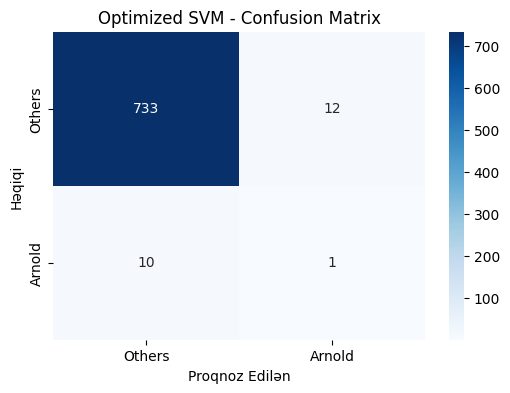

In [30]:
cm = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Others', 'Arnold'],
            yticklabels=['Others', 'Arnold'])
plt.title('Optimized SVM - Confusion Matrix')
plt.xlabel('Proqnoz Edilən')
plt.ylabel('Həqiqi')
plt.show()

22



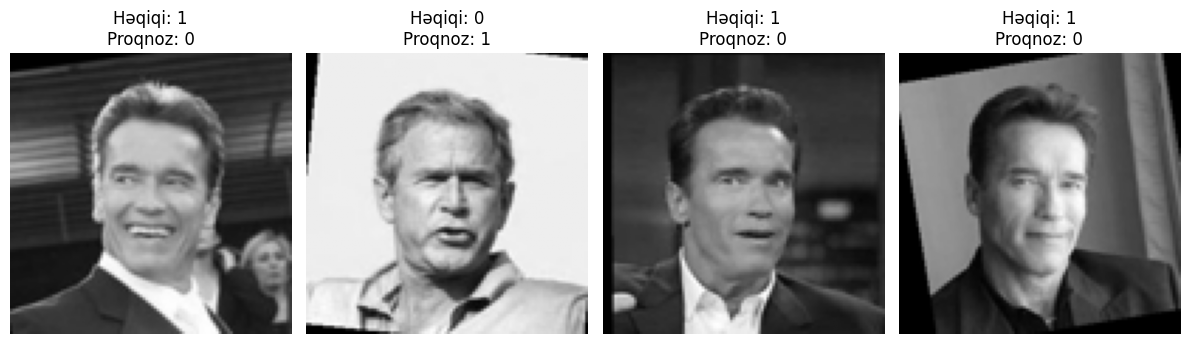

In [32]:
misclassified_indices = np.where(svm_preds != y_test)[0]

if len(misclassified_indices) > 0:
  print(len(misclassified_indices))
  print()

  plt.figure(figsize=(12, 4))
  for i, idx in enumerate(misclassified_indices[:4]):
      plt.subplot(1, 4, i + 1)
      plt.imshow(X_test[idx].reshape(images.shape[1], images.shape[2]), cmap='gray')
      plt.title(f"Həqiqi: {y_test[idx]}\nProqnoz: {svm_preds[idx]}")
      plt.axis('off')
  plt.tight_layout()
  plt.show()

else:
  print('Model test setində heç bir səhv etmədi')